In [1]:
%matplotlib inline

import time

import matplotlib.pyplot as plt
from num2words import num2words

In [2]:
num2words(123)

'one hundred and twenty-three'

In [3]:
class Dictionary:
    def set(self, key, value):
        pass

    def get(self, key):
        pass


In [4]:
class Dictionary:
    def __init__(self):
        self.keys = []
        self.values = []
    
    def set(self, key, value):
        self.keys.append(key)
        self.values.append(value)

    def get(self, key):
        for idx in range(len(self.keys)):
            if self.keys[idx] == key:
                return self.values[idx]


In [11]:
class Dictionary:
    def __init__(self, exp=8):
        self.exp = exp
        self.size = 2 ** exp
        self.keys = [None] * self.size
        self.values = [None] * self.size
        self.n_collisions = 0
    
    def set(self, key, value):
        idx = hash(key) % self.size

        while self.keys[idx] is not None:
            print('Collision!')
            idx = (idx + 1) % self.size
            self.n_collisions += 1

        self.keys[idx] = key
        self.values[idx] = value
        if self.n_collisions > 10:
            self._expand()

    def get(self, key):
        idx = hash(key) % self.size
        while self.keys[idx] != key:
            idx = (idx + 1) % self.size
        return self.values[idx]        

    def _expand(self):
        print('EXPANDING !!!')

        old_keys = self.keys
        old_values = self.values

        # Allocate more space
        self.exp = self.exp + 1
        self.size = 2 ** self.exp
        self.keys = [None] * self.size
        self.values = [None] * self.size
        self.n_collisions = 0

        # Reindex
        for idx, key in enumerate(old_keys):
            if key is not None:
                self.set(key, old_values[idx])



In [12]:
get_times = []
set_times = []

dict = Dictionary()

# --- STORE
N = 1000
values = range(N)
for value in values:
    key = num2words(value)

    start = time.time()
    print('Storing', key, value)
    dict.set(key, value)
    end = time.time()
    set_times.append(end - start)

# --- RETRIEVE
for value in values:
    key = num2words(value)

    start = time.time()
    retrieved = dict.get(key)
    print('Retrieved', key, retrieved)
    assert retrieved == value
    end = time.time()
    get_times.append(end - start)



Storing zero 0
Storing one 1
Storing two 2
Storing three 3
Storing four 4
Storing five 5
Storing six 6
Storing seven 7
Storing eight 8
Storing nine 9
Storing ten 10
Collision!
Storing eleven 11
Storing twelve 12
Storing thirteen 13
Storing fourteen 14
Storing fifteen 15
Storing sixteen 16
Storing seventeen 17
Storing eighteen 18
Storing nineteen 19
Storing twenty 20
Storing twenty-one 21
Storing twenty-two 22
Storing twenty-three 23
Storing twenty-four 24
Storing twenty-five 25
Storing twenty-six 26
Storing twenty-seven 27
Storing twenty-eight 28
Storing twenty-nine 29
Storing thirty 30
Storing thirty-one 31
Storing thirty-two 32
Storing thirty-three 33
Collision!
Storing thirty-four 34
Storing thirty-five 35
Storing thirty-six 36
Storing thirty-seven 37
Storing thirty-eight 38
Storing thirty-nine 39
Storing forty 40
Storing forty-one 41
Storing forty-two 42
Storing forty-three 43
Storing forty-four 44
Storing forty-five 45
Collision!
Collision!
Storing forty-six 46
Storing forty-seven

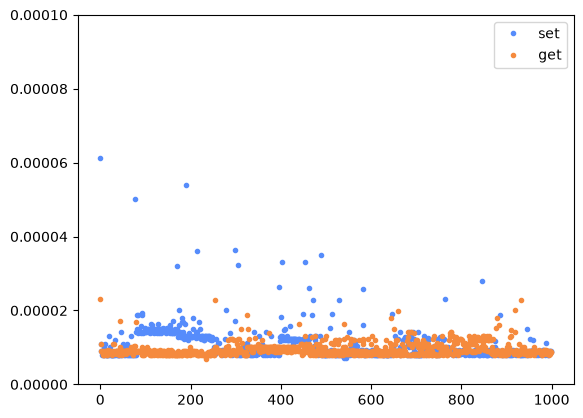

In [16]:
plt.plot(values, set_times, '../..', label='set')
plt.plot(values, get_times, '../..', label='get')
plt.legend()
plt.ylim(0, 0.0001)
plt.show()

